## Car Accident Detection Using YOLO

### DataSets
- ##### Car Detection
>  https://universe.roboflow.com/class-iq3mz/car-mqncf

- ##### Car Accident Detection
> https://universe.roboflow.com/fyp-projects-ttk43/accident-detection-xymwp

In [ ]:
import os
import random
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from ultralytics import YOLO

%matplotlib inline
warnings.filterwarnings('ignore')

In [ ]:
DATASET_PATH = r"merged_dataset"

yaml_content = f"""
path: {DATASET_PATH}

train: images/train
val: images/valid
test: images/test

nc: 2

names:
  0: accident
  1: normal
"""

yaml_path = "data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created")
print(yaml_content)


In [ ]:
from ultralytics import YOLO

if __name__ == '__main__': 
    
    model = YOLO(r"best.pt")

    results = model.train(
        data='data.yaml',
        
        epochs=30,       
        patience=15,       
        imgsz=640,          # Standard YOLO size
        batch=8,          
        lr0=0.001,         
        lrf=0.01,           
        device=0,
        workers=2,         
        cache=False,   
        augment=True,
        mosaic=1.0         
    )

    print("Training finished")

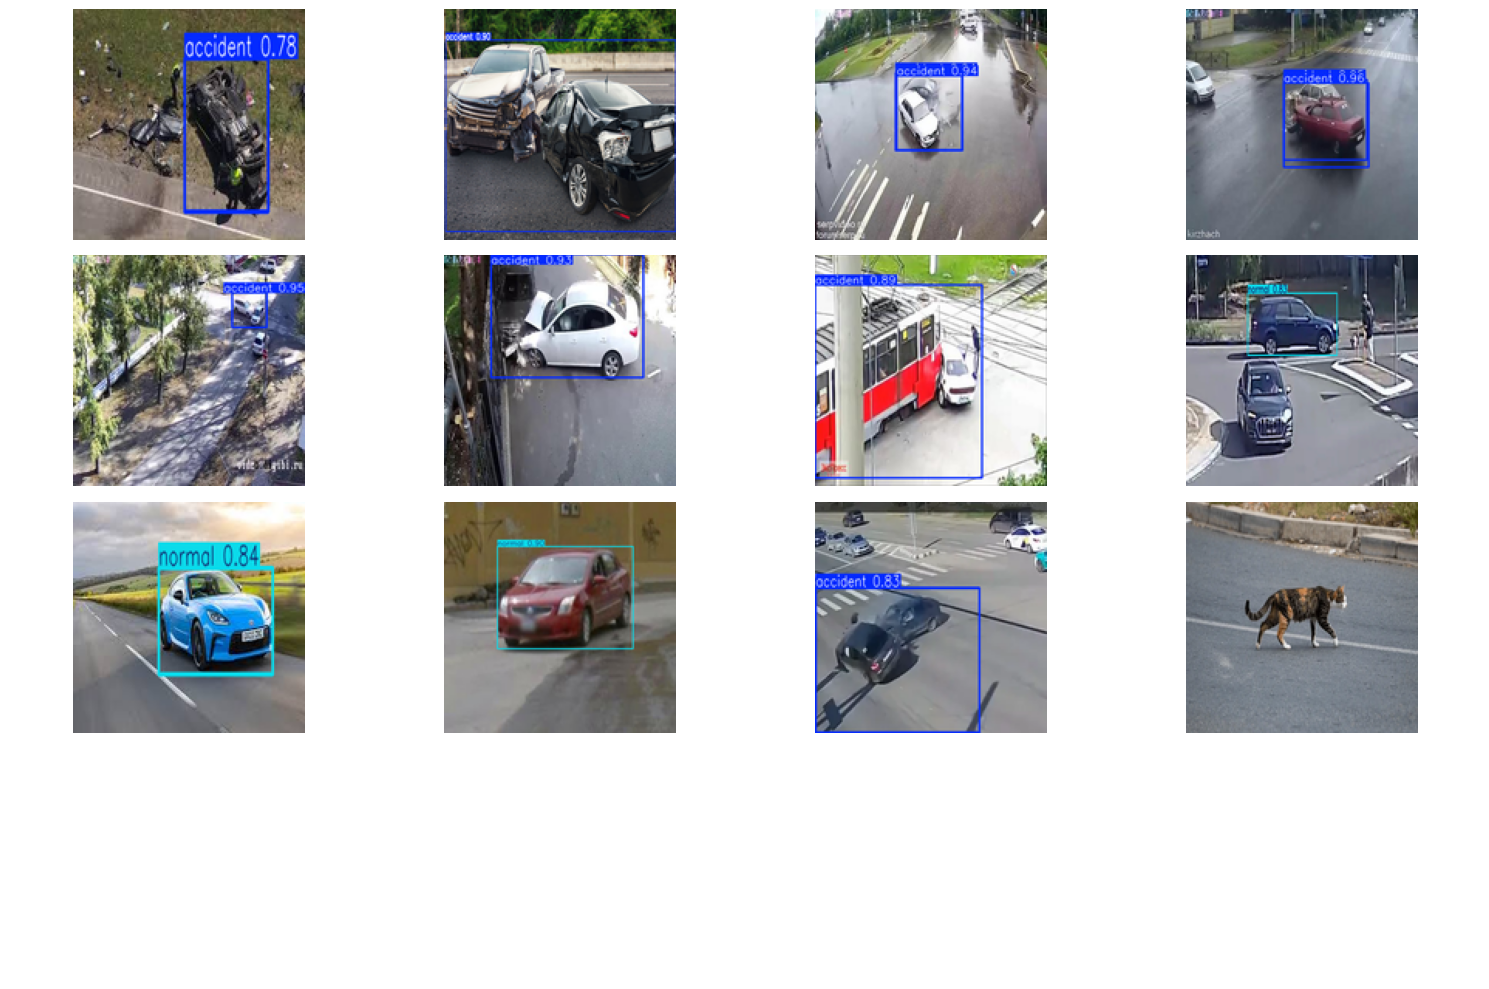

In [32]:
weights_path = r"best.pt"
model_prediction = YOLO(weights_path)

def detect_and_show_prediction(file_path, ax, confidence=0.78, target_size=(150, 150)):
    """
    Run detection using a single confidence threshold and Agnostic NMS.
    """
    results_prediction = model_prediction(file_path, conf=confidence, iou=0.45, agnostic_nms=True, verbose=False) 
    
    plotted_img = results_prediction[0].plot()
    plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)
 
    img_pil = Image.fromarray(plotted_img)
    img_resized = img_pil.resize(target_size, Image.LANCZOS)
    
    ax.imshow(np.array(img_resized))
    ax.axis('off')

img_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
image_dir = Path(r"D:\Programming\Rwad_Masr\Technical\DEPI_R4\project_trash\car.v1i.yolov8\images")

all_images = []
for ext in img_exts:
    all_images.extend(image_dir.glob(f"*{ext}"))

fig, axes = plt.subplots(4, 4, figsize=(15, 10))
axes_flat = axes.flatten()

for img_path_obj, ax in zip(all_images, axes_flat):
    detect_and_show_prediction(str(img_path_obj), ax)

for ax in axes_flat[len(all_images):]:
    ax.axis('off')

plt.tight_layout()
# plt.savefig("output_predictions.jpg", dpi=300, bbox_inches='tight')
plt.show()

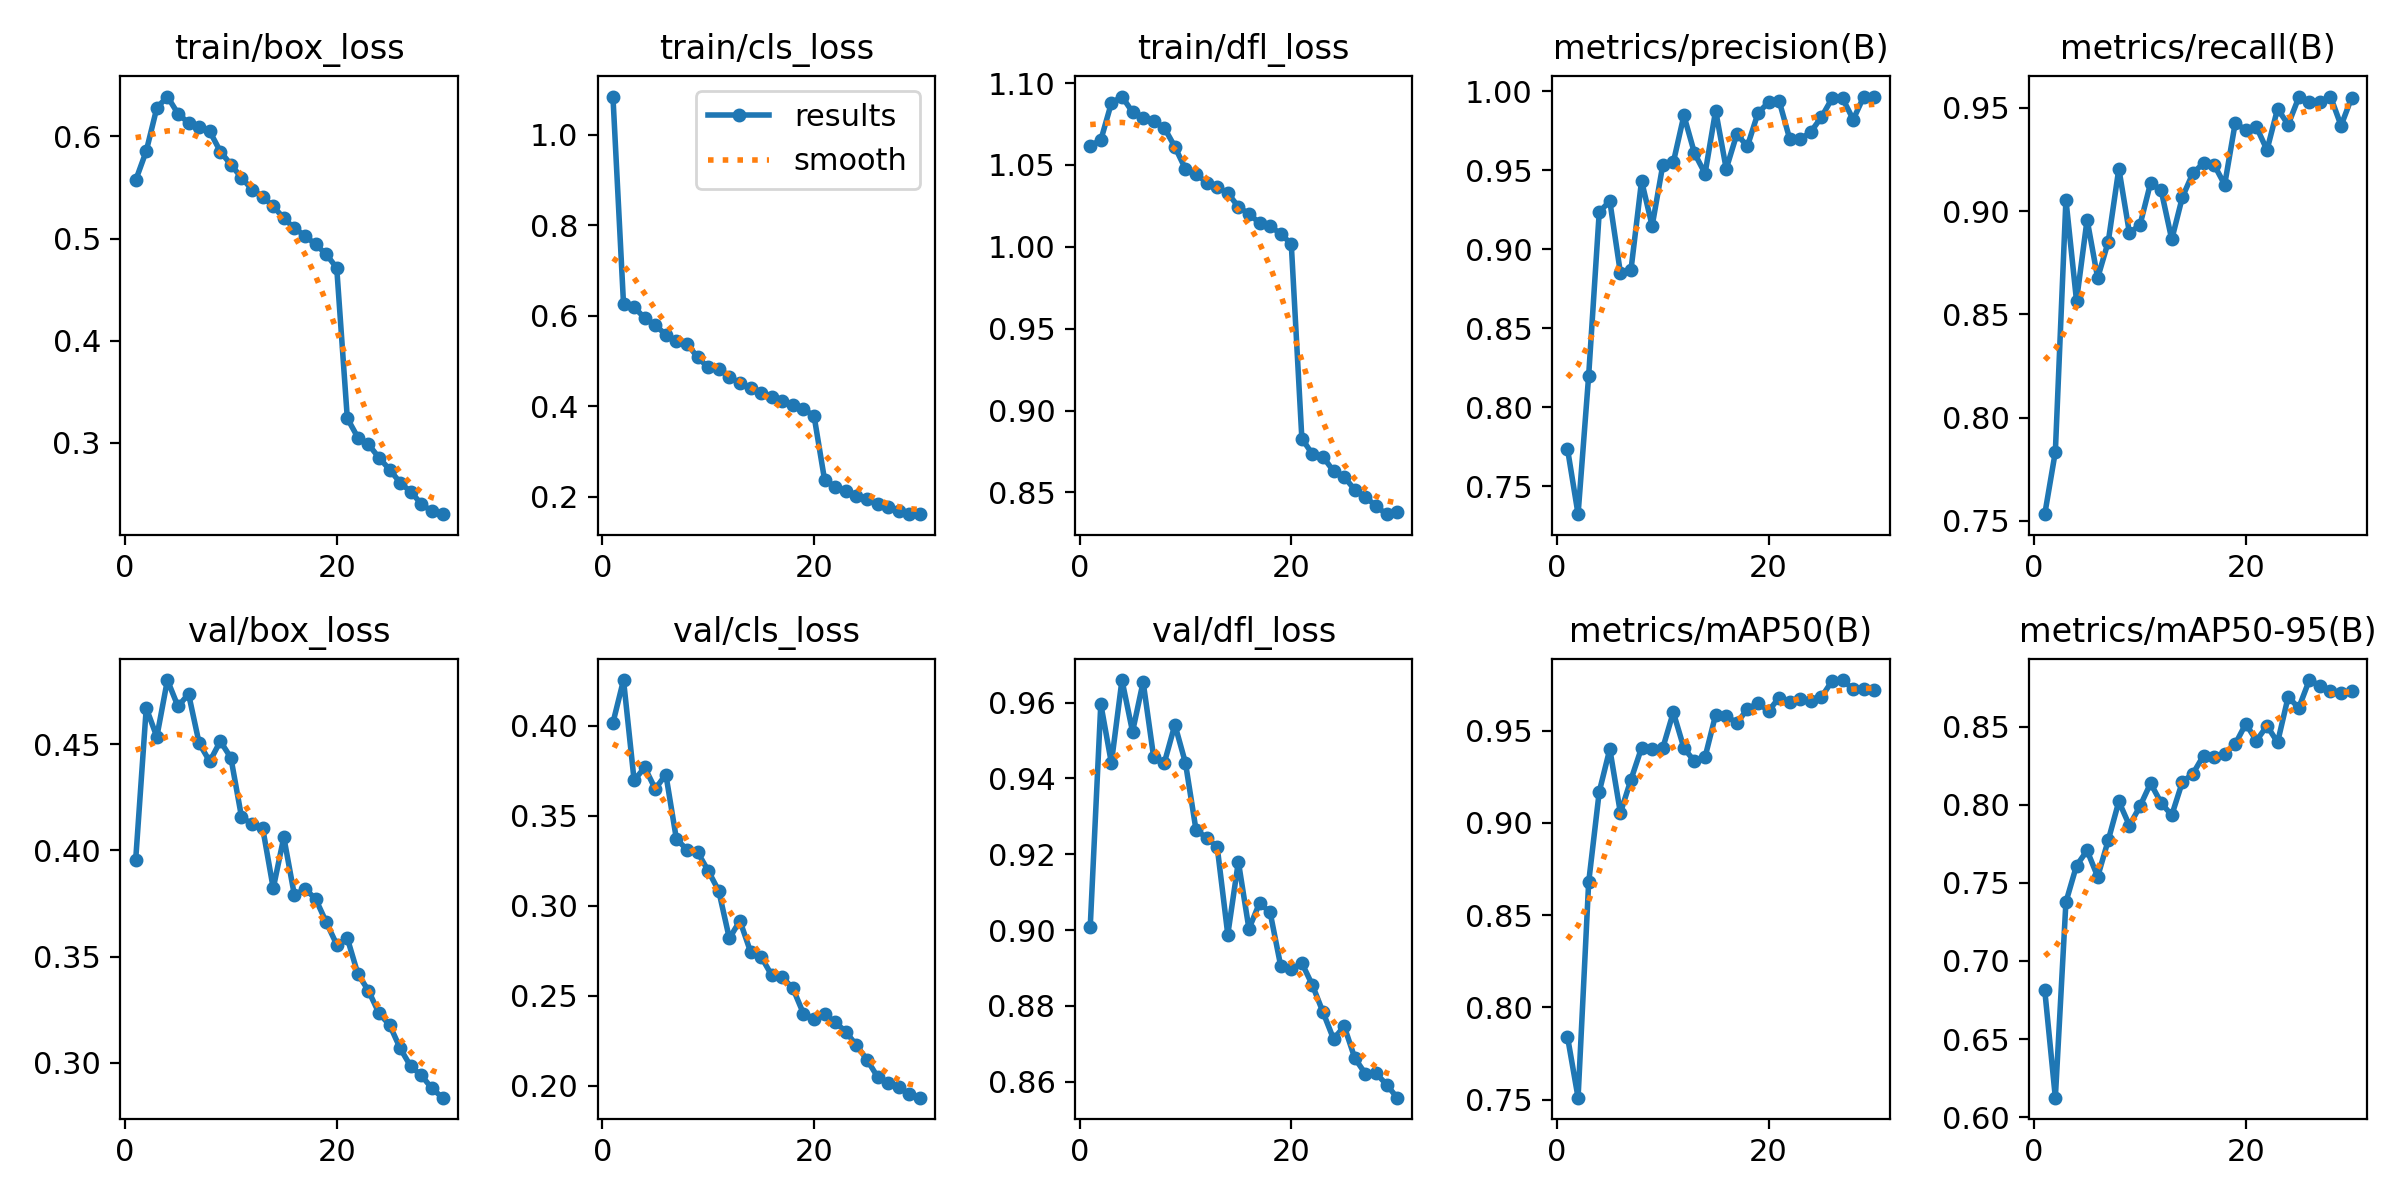

In [ ]:
train_results = r"results\results.png"

img = Image.open(train_results) 
display(img) 


In [21]:
df=pd.read_csv(r"results\results.csv")

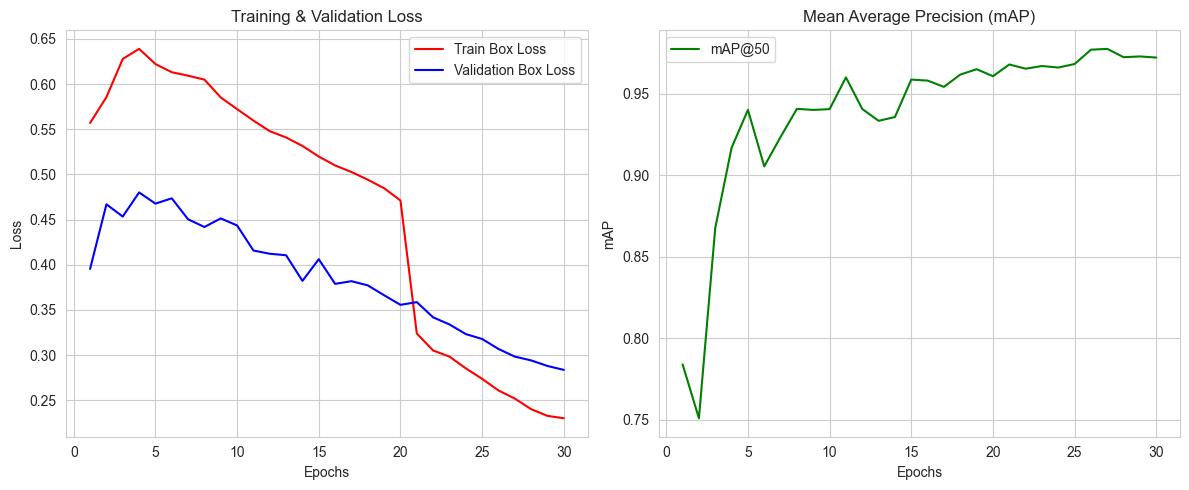

In [ ]:
map_column = "metrics/mAP50(B)" 
loss_column_train = "train/box_loss"
loss_column_val = "val/box_loss"

plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")

# Plot Train Loss and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df[loss_column_train], label="Train Box Loss", color="red")
plt.plot(df["epoch"], df[loss_column_val], label="Validation Box Loss", color="blue")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# Plot mAP@50
plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df[map_column], label="mAP@50", color="green")
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("Mean Average Precision (mAP)")

plt.legend()

plt.tight_layout()
plt.show()

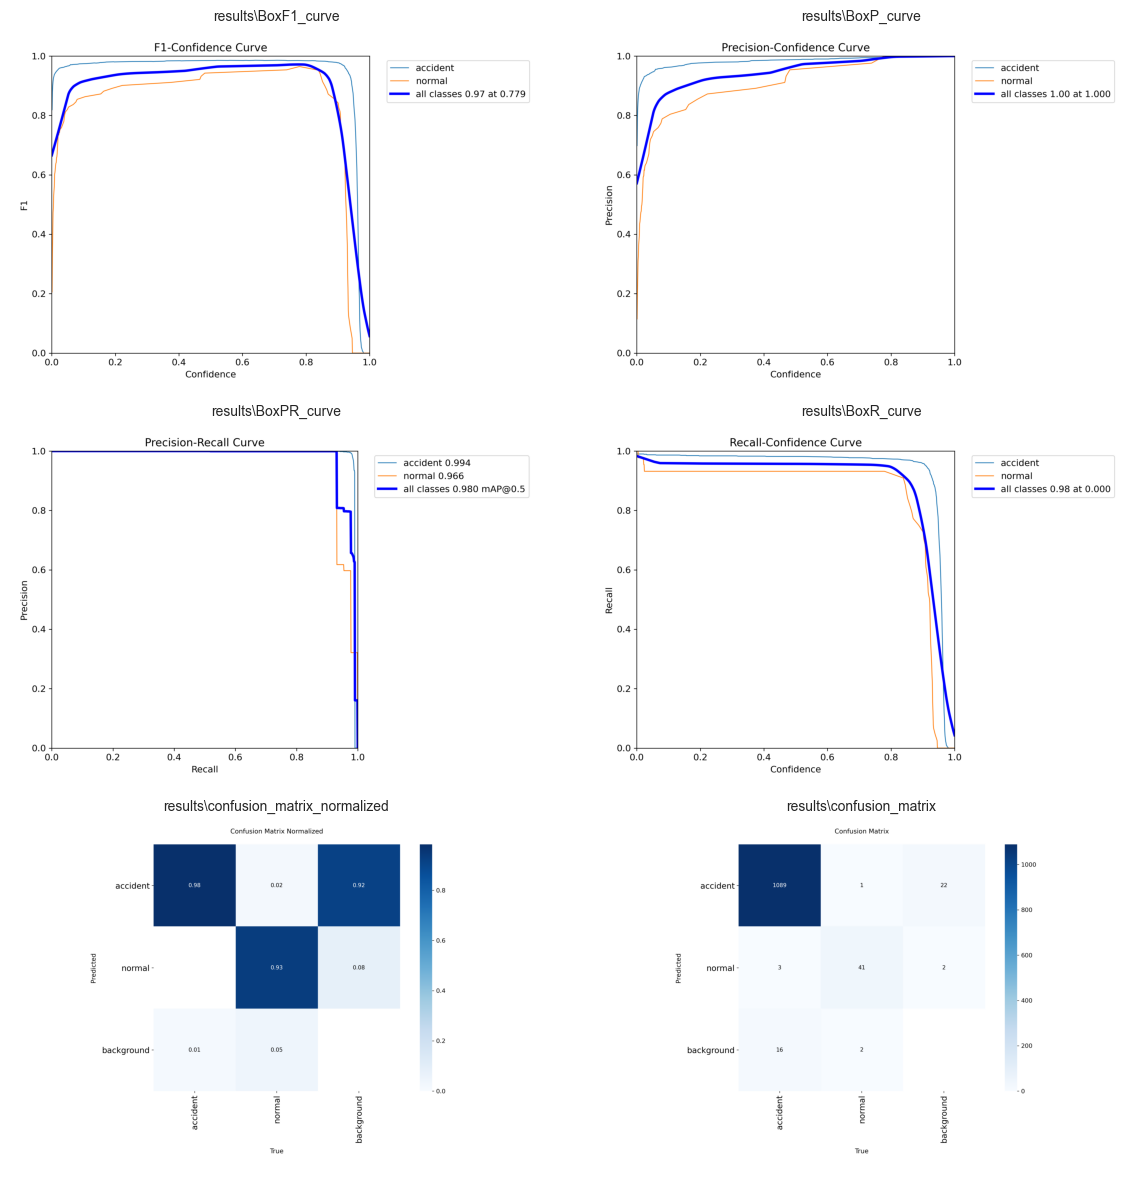

In [ ]:
image_files = [
    'results\BoxF1_curve.png',
    'results\BoxP_curve.png', 
    'results\BoxPR_curve.png',
    'results\BoxR_curve.png',
    'results\confusion_matrix_normalized.png',
    'results\confusion_matrix.png'
]

n_images = len(image_files)
cols = 2 
rows = (n_images + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten() 

for idx, img_file in enumerate(image_files):
    if os.path.exists(img_file):
        img = plt.imread(img_file)
        axes[idx].imshow(img)
        axes[idx].set_title(img_file.replace('.png', ''), fontsize=10, pad=10)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'{img_file}\nNot Found', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].axis('off')

for idx in range(len(image_files), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()